# Exploratory Data Analysis of Online Retail Sales

### CodeAlpha Data Analytics Internship — Task 2

**Project Type:** Exploratory Data Analysis (EDA)

**Dataset:** Online Retail Dataset
### Objective

To explore and analyze online retail sales data to identify sales trends, top-performing products, customer purchasing patterns, country-wise sales, and other key business insights.

## Dataset Information

The Online Retail dataset contains transaction records from an online retail store.

### Dataset Features

| Column | Description |
|---|---|
| InvoiceNo | Invoice number for each transaction |
| StockCode | Product/item code |
| Description | Product description |
| Quantity | Number of items purchased |
| InvoiceDate | Date and time of the transaction |
| UnitPrice | Price per item |
| CustomerID | Unique customer identifier |
| Country | Country of the customer |

### Dataset Period

The transaction data used in this analysis ranges from **December 1, 2010 to December 9, 2011**.

In [1]:
import pandas as pd

## Import Libraries

The following Python libraries are used for data analysis and visualization:

- **Pandas** – for data manipulation and analysis.
- **NumPy** – for numerical calculations.
- **Matplotlib** – for creating visualizations.

## Load the Dataset

The Online Retail dataset was extracted from the ZIP file and loaded into a Pandas DataFrame for analysis.

In [2]:
!unzip -o online+retail.zip

Archive:  online+retail.zip
 extracting: Online Retail.xlsx      


In [3]:
!ls

'Online Retail.xlsx'   online+retail.zip   sample_data


In [4]:
df = pd.read_excel("Online Retail.xlsx")

## Initial Data Exploration

The dataset was initially explored to understand its structure, size, columns, and basic contents.

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


## Data Cleaning

In [9]:
df.dropna()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [10]:
df.duplicated().sum()

np.int64(5268)

In [11]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [12]:
df[df["Quantity"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [13]:
df["UnitPrice"].describe()

,UnitPrice
count,541909.000000
mean,4.611114
std,96.759853
min,-11062.060000
25%,1.250000
50%,2.080000
75%,4.130000
max,38970.000000


In [14]:
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [15]:
df["Sales"] = df["Quantity"] * df["UnitPrice"]

In [16]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [17]:
df["Sales"].sum()

np.float64(9747747.933999998)

In [18]:
country_sales = df.groupby("Country")["Sales"].sum().sort_values(ascending=False)

In [19]:
country_sales.head(10)

,Sales
Country,
United Kingdom,8187806.364
Netherlands,284661.540
EIRE,263276.820
Germany,221698.210
France,197403.900
Australia,137077.270
Switzerland,56385.350
Spain,54774.580
Belgium,40910.960


## Data Visualization

Visualizations were created using Matplotlib to identify sales trends and patterns in the retail data.

In [20]:
import matplotlib.pyplot as plt

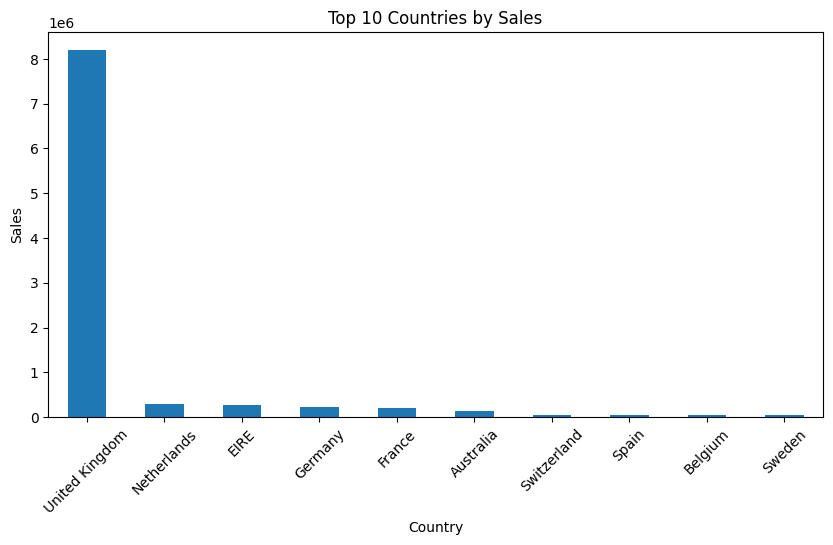

In [21]:
country_sales.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [22]:
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
 8   Sales        541909 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 37.2+ MB


np.int64(5268)

In [23]:
(df["Quantity"] < 0).sum()

np.int64(10624)

In [24]:
df[df["Quantity"] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96


In [26]:
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

In [27]:
(df["Sales"] < 0).sum()

np.int64(9290)

In [28]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [29]:
df["Description"].isnull().sum()
df = df.dropna(subset=["Description"])
df["Description"].isnull().sum()

np.int64(0)

In [30]:
sales_df = df[df["Quantity"] > 0].copy()
sales_df.shape
sales_df["Quantity"].min()

1

In [31]:
df = pd.read_excel("Online Retail.xlsx")

In [32]:
!unzip -o online+retail.zip

Archive:  online+retail.zip
 extracting: Online Retail.xlsx      


In [33]:
!ls

'Online Retail.xlsx'   online+retail.zip   sample_data


In [34]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

In [35]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [36]:
df = df.drop_duplicates()

In [37]:
df["Description"].isnull().sum()

np.int64(1454)

In [38]:
df = df.dropna(subset=["Description"])

In [39]:
df["Description"].isnull().sum()

np.int64(0)

In [40]:
df["CustomerID"].isnull().sum()

np.int64(133583)

In [41]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9251)

In [43]:
sales_df = df[df["Quantity"] > 0].copy()
sales_df.shape

(525462, 8)

In [44]:
sales_df["Quantity"].min()

1

In [45]:
(sales_df["UnitPrice"] <= 0).sum()

np.int64(584)

In [46]:
sales_df = sales_df[sales_df["UnitPrice"] > 0].copy()
sales_df["UnitPrice"].min()

0.001

In [47]:
sales_df.shape

(524878, 8)

In [48]:
sales_df["Sales"] = sales_df["Quantity"] * sales_df["UnitPrice"]
sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [49]:
sales_df["Sales"].describe()

,Sales
count,524878.000000
mean,20.275399
std,271.693566
min,0.001000
25%,3.900000
50%,9.920000
75%,17.700000
max,168469.600000


In [50]:
total_sales = sales_df["Sales"].sum()
total_sales

np.float64(10642110.804)

In [51]:
total_transactions = sales_df["InvoiceNo"].nunique()
total_transactions

19960

In [52]:
unique_products = sales_df["StockCode"].nunique()
unique_products

3922

In [53]:
unique_countries = sales_df["Country"].nunique()
unique_countries

38

In [54]:
total_sales = sales_df["Sales"].sum()
total_sales

np.float64(10642110.804)

In [55]:
total_transactions = sales_df["InvoiceNo"].nunique()
total_transactions

19960

In [56]:
unique_products = sales_df["StockCode"].nunique()
unique_products

3922

In [58]:
unique_countries = sales_df["Country"].nunique()
unique_countries

38

In [59]:
sales_df.sort_values(by="Sales", ascending=False).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098.0,United Kingdom,38970.00
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,13541.33
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom,11062.06
173382,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029.0,United Kingdom,8142.75
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,2011-09-20 11:05:00,5.06,17450.0,United Kingdom,7144.72
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,6539.40
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,6539.40
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2011-10-27 12:11:00,2.08,14646.0,Netherlands,4992.00


In [60]:
sales_df["Sales"].quantile([0.90, 0.95, 0.99])

,Sales
0.90,33.0
0.95,59.8
0.99,183.6


In [61]:
Q1 = sales_df["Sales"].quantile(0.25)
Q3 = sales_df["Sales"].quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

Q1, Q3, IQR, upper_limit

(np.float64(3.9),
 np.float64(17.700000000000003),
 np.float64(13.800000000000002),
 np.float64(38.400000000000006))

In [62]:
(sales_df["Sales"] > upper_limit).sum()

np.int64(42624)

## Product Analysis

In [63]:
product_quantity = sales_df.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

In [64]:
product_quantity.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
JUMBO BAG RED RETROSPOT,48371
WHITE HANGING HEART T-LIGHT HOLDER,37872
POPCORN HOLDER,36749
PACK OF 72 RETROSPOT CAKE CASES,36396
ASSORTED COLOUR BIRD ORNAMENT,36362
RABBIT NIGHT LIGHT,30739


In [65]:
product_sales = sales_df.groupby("Description")["Sales"].sum().sort_values(ascending=False)

In [66]:
product_sales.head(10)

,Sales
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


In [67]:
country_sales = sales_df.groupby("Country")["Sales"].sum().sort_values(ascending=False)

In [68]:
country_sales.head(10)

,Sales
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


## Time-Based Analysis

In [69]:
sales_df["InvoiceDate"].min(), sales_df["InvoiceDate"].max()

(Timestamp('2010-12-01 08:26:00'), Timestamp('2011-12-09 12:50:00'))

In [70]:
sales_df["Month"] = sales_df["InvoiceDate"].dt.to_period("M")

In [71]:
sales_df[["InvoiceDate", "Month"]].head()

,InvoiceDate,Month
0,2010-12-01 08:26:00,2010-12
1,2010-12-01 08:26:00,2010-12
2,2010-12-01 08:26:00,2010-12
3,2010-12-01 08:26:00,2010-12
4,2010-12-01 08:26:00,2010-12


In [72]:
monthly_sales = sales_df.groupby("Month")["Sales"].sum()

In [73]:
monthly_sales

,Sales
Month,
2010-12,821452.730
2011-01,689811.610
2011-02,522545.560
2011-03,716215.260
2011-04,536968.491
2011-05,769296.610
2011-06,760547.010
2011-07,718076.121
2011-08,757841.380


In [75]:
monthly_transactions = sales_df.groupby("Month")["InvoiceNo"].nunique()

In [76]:
monthly_transactions

,InvoiceNo
Month,
2010-12,1559
2011-01,1086
2011-02,1100
2011-03,1454
2011-04,1246
2011-05,1681
2011-06,1533
2011-07,1475
2011-08,1361


## Customer Analysis

In [77]:
sales_df["CustomerID"].nunique()

4338

In [78]:
customer_sales = sales_df.groupby("CustomerID")["Sales"].sum().sort_values(ascending=False)

In [79]:
customer_sales.head(10)

,Sales
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


In [80]:
customer_transactions = sales_df.groupby("CustomerID")["InvoiceNo"].nunique().sort_values(ascending=False)

In [81]:
customer_transactions.head(10)

,InvoiceNo
CustomerID,
12748.0,209
14911.0,201
17841.0,124
13089.0,97
14606.0,93
15311.0,91
12971.0,86
14646.0,73
16029.0,63


In [82]:
sales_df[["Quantity", "UnitPrice", "Sales"]].corr()

,Quantity,UnitPrice,Sales
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
Sales,0.907402,0.137381,1.000000


In [83]:
sales_df[["Quantity", "UnitPrice", "Sales"]].corr()

,Quantity,UnitPrice,Sales
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
Sales,0.907402,0.137381,1.000000


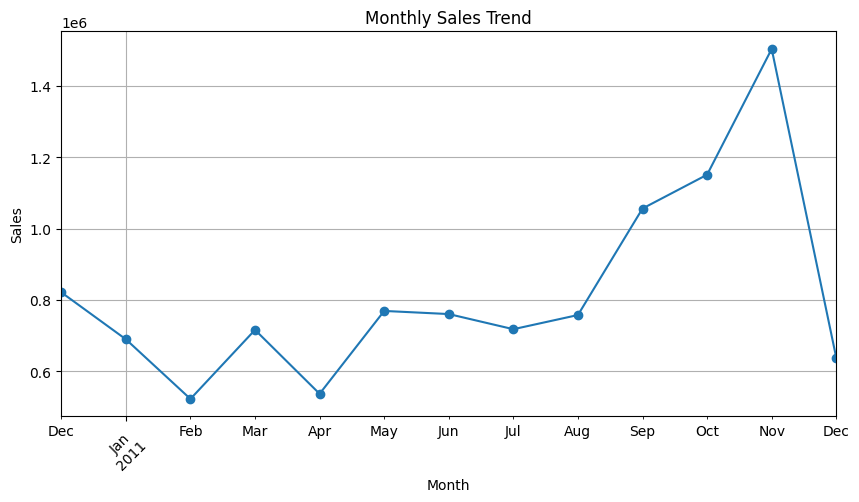

In [84]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", figsize=(10,5), marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

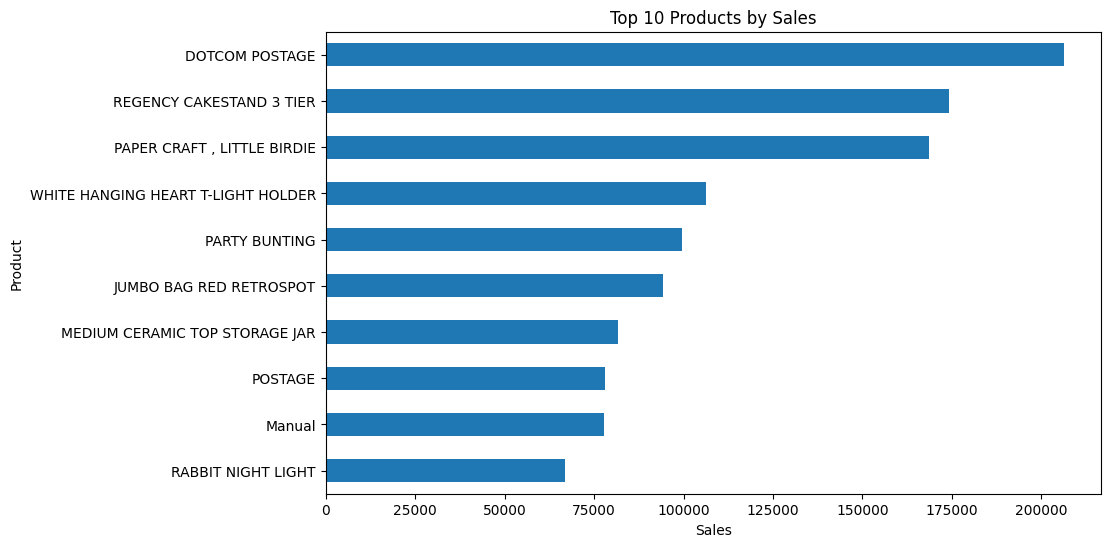

In [85]:
top_products = product_sales.head(10)

top_products.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

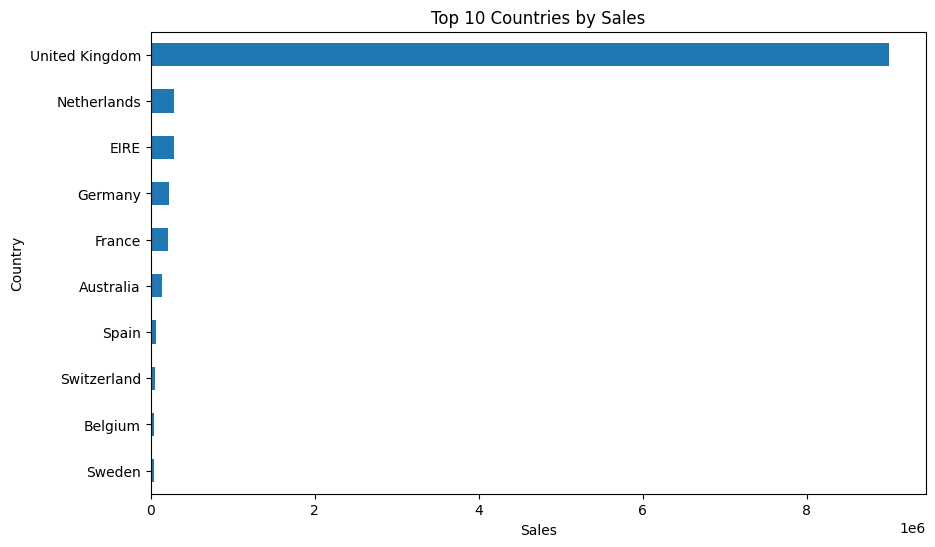

In [86]:
top_countries = country_sales.head(10)

top_countries.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Countries by Sales")
plt.xlabel("Sales")
plt.ylabel("Country")
plt.show()

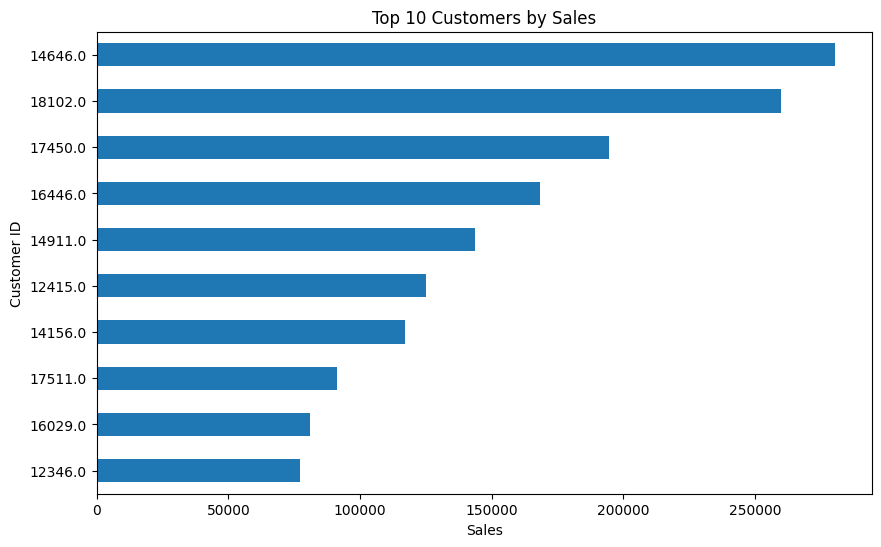

In [87]:
top_customers = customer_sales.head(10)

top_customers.sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Sales")
plt.ylabel("Customer ID")
plt.show()

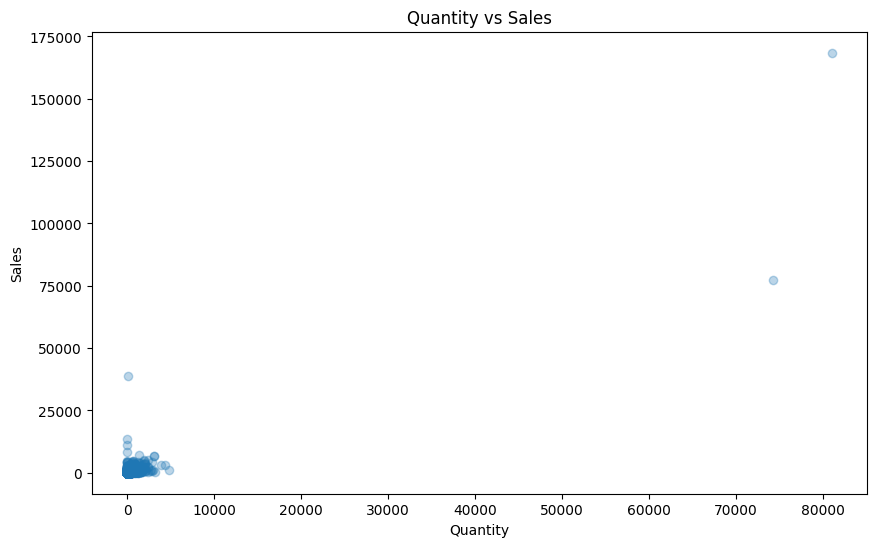

In [88]:
plt.figure(figsize=(10,6))

plt.scatter(
    sales_df["Quantity"],
    sales_df["Sales"],
    alpha=0.3
)

plt.title("Quantity vs Sales")
plt.xlabel("Quantity")
plt.ylabel("Sales")
plt.show()

## Correlation Analysis

In [90]:
sales_df[["Quantity", "UnitPrice", "Sales"]].corr()

,Quantity,UnitPrice,Sales
Quantity,1.000000,-0.003788,0.907402
UnitPrice,-0.003788,1.000000,0.137381
Sales,0.907402,0.137381,1.000000


In [89]:
total_sales / total_transactions

np.float64(533.1718839679359)

## Key Findings

- The dataset contains online retail transactions from December 2010 to December 2011.
- The total sales generated in the cleaned sales data are approximately £10.64 million.
- The analysis contains 19,960 unique transactions and 3,922 unique products.
- The United Kingdom contributes the largest share of sales among the countries analyzed.
- November 2011 recorded the highest monthly sales during the analyzed period.
- Product-level analysis identified the products generating the highest sales and the products with the highest quantities sold.
- Customer analysis identified customers with the highest total sales and the highest number of transactions.
- The correlation analysis showed a strong positive relationship between Quantity and Sales.
- The IQR method identified unusually high sales values; these were not automatically removed because some may represent legitimate bulk transactions.

## Conclusion

The Exploratory Data Analysis provided useful insights into the sales performance of the online retail dataset. The analysis examined sales trends, product performance, country-wise sales, customer purchasing patterns, transaction activity, and relationships between quantity, unit price, and sales.

The results show that sales varied across months, countries, products, and customers. The analysis also identified unusually high transaction values and examined them using statistical methods such as percentiles and the IQR method.

Overall, the EDA helped identify important patterns and characteristics in the retail transaction data and provided a foundation for further data analysis and visualization.